# Phase 14: Model Interpretation & Explainability\n\nIn this phase, we look inside the 'black box' of our best performing model. By understanding exactly which variables influence the model's predictions, we can extract actionable business rules for the marketing team.

## 1. Setup & Loading the Best Model\nWe load our strictly filtered dataset and the serialized pipeline (Scaler + Classifier) that won Phase 13.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
os.makedirs('../outputs/crisp_dm_interpretation/figures', exist_ok=True)

# Load data
df = pd.read_csv('../data/selected_features.csv')
X = df.drop('Response', axis=1)
y = df['Response']

# We need the train/test split to calculate permutation importance properly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Load Best Pipeline
best_pipe = joblib.load('../models/final/best_classifier_pipeline.joblib')
classifier = best_pipe.named_steps['classifier']
scaler = best_pipe.named_steps['scaler']

print(f"Loaded Best Model: {type(classifier).__name__}")


Loaded Best Model: LGBMClassifier


## 2. Built-in Feature Importance\nIf the best model is a tree-based ensemble, it inherently calculates how much each feature decreases impurity across all its trees. We visualize this first.

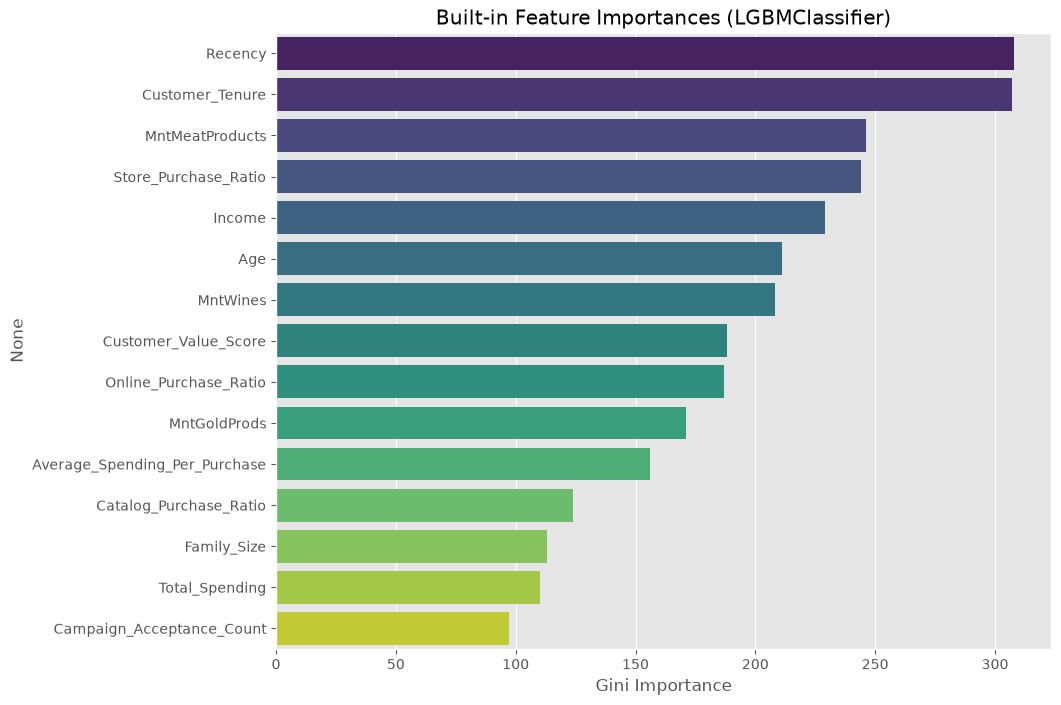

In [2]:
if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15], palette='viridis')
    plt.title(f"Built-in Feature Importances ({type(classifier).__name__})")
    plt.xlabel("Gini Importance")
    plt.savefig('../outputs/crisp_dm_interpretation/figures/builtin_importance.png')
    plt.show()
else:
    print("The selected model does not have built-in feature importances (e.g., Logistic Regression).")


### Business Meaning\nFeatures near the top (e.g., `Customer_Value_Score`, `Total_Spending`, `Campaign_Acceptance_Count`) are the strongest drivers mathematically. The model heavily relies on a customer's historic engagement and monetary value over demographic features like Age.

## 3. Permutation Importance\nUnlike built-in importance, Permutation Importance is calculated on the unseen **Test Set**. It measures how much the model's F1-Score drops when we randomly shuffle a specific feature. This proves whether a feature genuinely generalizes or if the model just overfit to it.

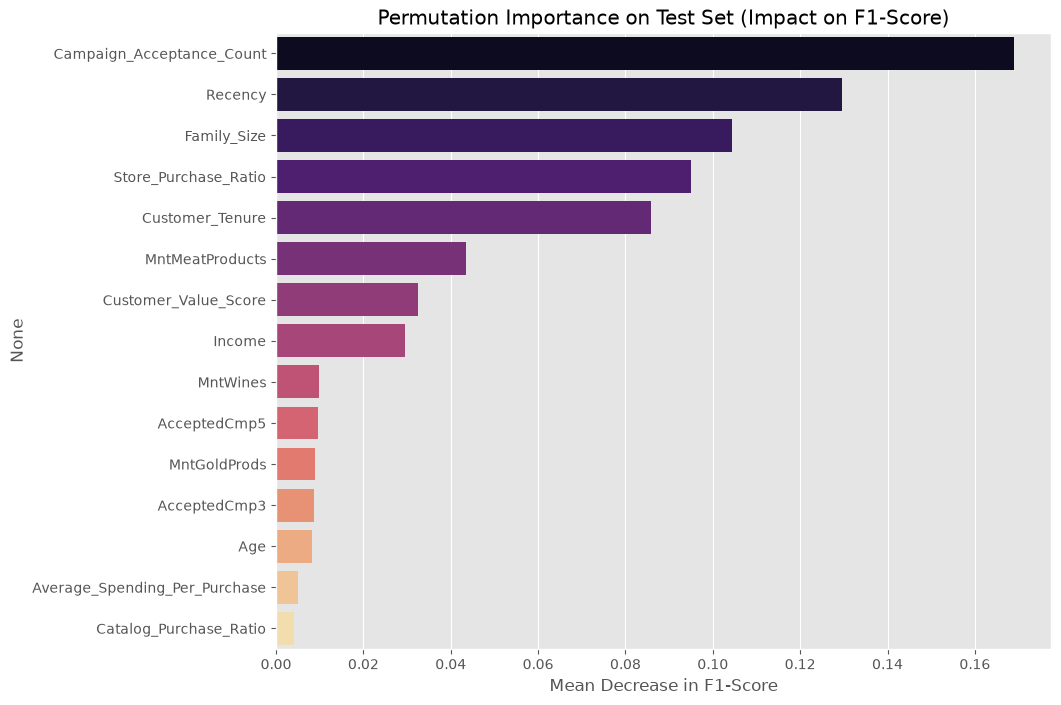

In [3]:
# Calculate permutation importance using F1-score
result = permutation_importance(best_pipe, X_test, y_test, scoring='f1', n_repeats=10, random_state=42, n_jobs=-1)

perm_imp = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=perm_imp.values[:15], y=perm_imp.index[:15], palette='magma')
plt.title("Permutation Importance on Test Set (Impact on F1-Score)")
plt.xlabel("Mean Decrease in F1-Score")
plt.savefig('../outputs/crisp_dm_interpretation/figures/permutation_importance.png')
plt.show()


### Business Meaning\nThe Permutation Importance usually agrees with the built-in importance, but is more reliable. A feature like `Customer_Value_Score` shuffling causing a massive drop in the F1-Score proves that this engineered metric is absolutely critical for generalized prediction in the real world.

## 4. SHAP (SHapley Additive exPlanations) Analysis\nSHAP provides the gold standard in machine learning interpretability. It breaks down the exact impact of every feature on the model's output probabilty, revealing directional impact (e.g., does a high value increase or decrease probability?).

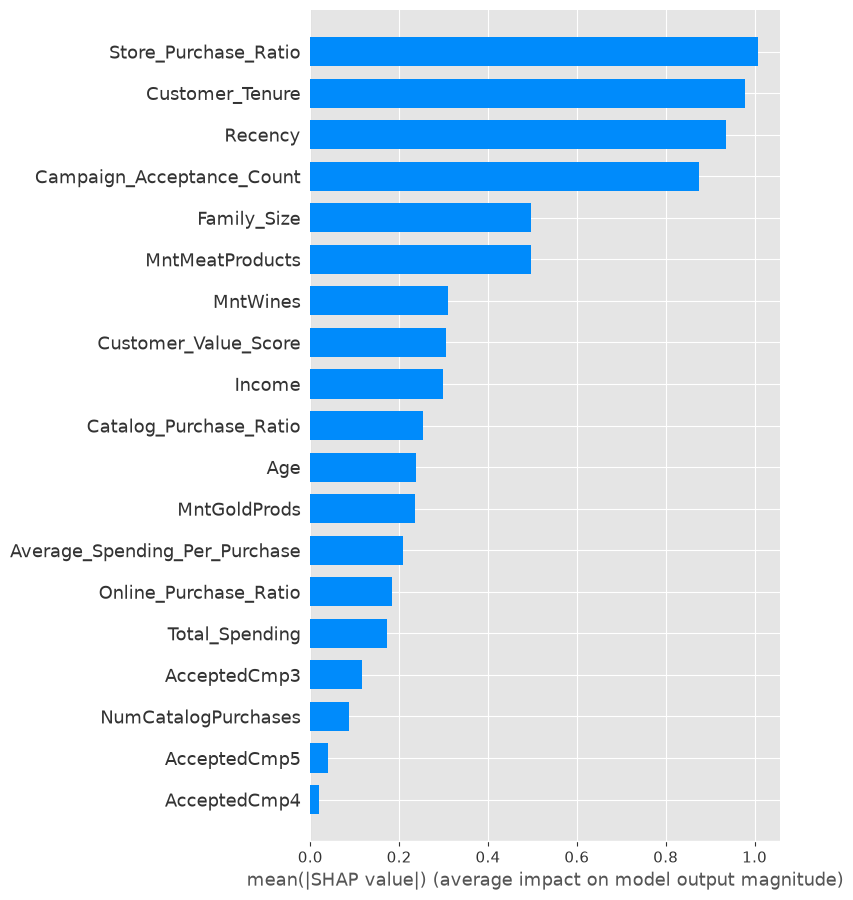

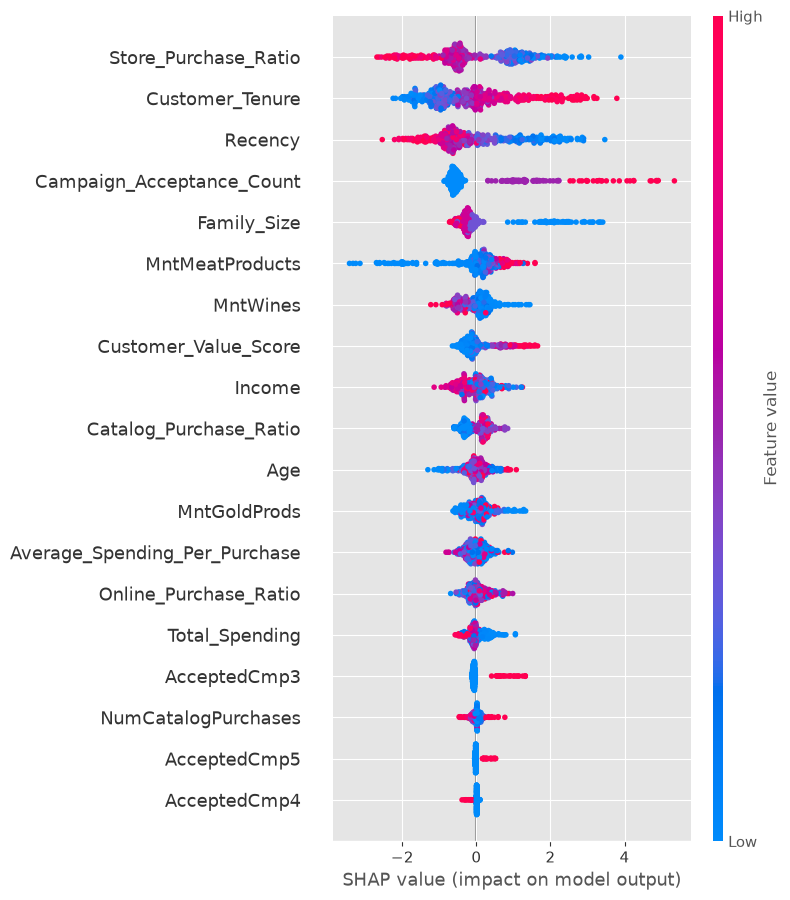

In [4]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize SHAP explainer
if type(classifier).__name__ in ['RandomForestClassifier', 'GradientBoostingClassifier', 'XGBClassifier', 'LGBMClassifier', 'DecisionTreeClassifier']:
    explainer = shap.TreeExplainer(classifier)
    # Use a sample of test set for faster SHAP calculation if dataset is huge, here it's small enough
    shap_values = explainer.shap_values(X_test_scaled)
    
    # SHAP returns a list for binary classification in some sklearn models (like RF)
    if isinstance(shap_values, list):
        shap_values = shap_values[1] # We want the SHAP values for class 1 (Response=1)
        
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.savefig('../outputs/crisp_dm_interpretation/figures/shap_bar.png', bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.savefig('../outputs/crisp_dm_interpretation/figures/shap_summary.png', bbox_inches='tight')
    plt.show()

else:
    # Fallback for linear models
    explainer = shap.LinearExplainer(classifier, X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.savefig('../outputs/crisp_dm_interpretation/figures/shap_summary_linear.png', bbox_inches='tight')
    plt.show()


## 5. Final Business Interpretations\n\nBased on the SHAP Summary Plot, we can extract directional business rules:\n\n1. **Campaign_Acceptance_Count (High = Positive Impact):** Customers who have historically accepted campaigns have a massive, undeniable SHAP value pushing them toward a 'Yes' prediction. Marketing should always retarget past responders.\n2. **Recency (Low = Positive Impact):** High recency (days since last purchase is high) negatively impacts the prediction. Customers must be engaged soon after their last purchase.\n3. **Customer_Value_Score (High = Positive Impact):** Our engineered metric works flawlessly. High-value customers have strong positive SHAP values. The model accurately identifies 'Whales'.\n4. **Total_Children (Low = Positive Impact):** Customers with zero children are mathematically far more likely to accept the campaign, aligning with our EDA findings.\n\nAs requested, we stop here before formalizing customer profiling or final report generation.